# Exercícios Probabilidade e Amostragem | Bootcamp Data Analytics | WomakersCode

Este projeto foi criado para responder os exercícios propostos pelo bootcamp de **Data Analytics** da **WomakersCode**. Ele consiste na análise estatística de uma base de dados fictícia da população brasileira, focando em conceitos de Probabilidade e Amostragem. O objetivo é analisar características da força de trabalho (como renda, escolaridade e proficiência em inglês) utilizando distribuições probabilísticas, testes de amostragem e cálculo de margens de erro.  

---

A premissa do projeto disponibilizado pela WomakersCode é:  

Considerando a base de dados de *populacao_brasileira.csv* responda as
questões (os dados são fictícios).  

Você é uma pesquisadora desenvolvendo uma análise sobre as
características da força de trabalho nos estados brasileiros. Responda aos Exercícios.


## Importações e primeiras impressões:

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [51]:
url = 'https://raw.githubusercontent.com/nagelamartins/probabilidade-amostragem/refs/heads/main/populacao_brasileira.csv'
df = pd.read_csv(url)
df.head(10)

,Unnamed: 0,estado,idade,escolaridade,nível de proficiência em inglês,renda,sexo
0,0,MA,56,Fundamental,Intermediário,4006.29,F
1,1,BA,46,Superior,Básico,2423.11,M
2,2,AM,32,Fundamental,Intermediário,3835.69,M
3,3,CE,60,Superior,Básico,1870.29,M
4,4,SE,25,Fundamental,Avançado,3529.80,M
5,5,AM,38,Fundamental,Avançado,4441.57,F
6,6,DF,56,Médio,Intermediário,528.36,F
7,7,DF,36,Superior,Avançado,2203.10,F
8,8,PI,40,Fundamental,Básico,3577.07,F
9,9,AP,28,Superior,Avançado,2796.95,M


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       1000 non-null   int64  
 1   estado                           1000 non-null   object 
 2   idade                            1000 non-null   int64  
 3   escolaridade                     1000 non-null   object 
 4   nível de proficiência em inglês  1000 non-null   object 
 5   renda                            1000 non-null   float64
 6   sexo                             1000 non-null   object 
dtypes: float64(1), int64(2), object(4)
memory usage: 54.8+ KB


É possível verificar que existem 1000 registros dividos em 7 colunas: uma do tipo `float`, 2 do tipo `int` e 4 do tipo `str`. Não há resgistros nulos.

In [53]:
df.describe()

,Unnamed: 0,idade,renda
count,1000.000000,1000.000000,1000.000000
mean,499.500000,40.986000,3082.537180
std,288.819436,13.497852,996.572239
min,0.000000,18.000000,103.740000
25%,249.750000,29.000000,2425.815000
50%,499.500000,42.000000,3076.415000
75%,749.250000,52.000000,3714.487500
max,999.000000,64.000000,5632.380000


Verificando a coluna `'Unnamed: 0'`, entende-se que se trata de um número de ID. Para facilitar a compreensão, essa coluna é renomeada.

In [54]:
df.rename(columns={'Unnamed: 0': 'ID'}, inplace = True)
df.columns

Index(['ID', 'estado', 'idade', 'escolaridade',
       'nível de proficiência em inglês', 'renda', 'sexo'],
      dtype='object')

Verificando os valores únicos das colunas do tipo `str (object)` para facilitar o uso posterior nas análises.

In [55]:
colunas_object = df.select_dtypes(include=['object']).columns

for coluna in colunas_object:
    print(f'Coluna: {coluna} \nValores únicos:')
    print(df[coluna].unique())
    print("-" * 30)

Coluna: estado 
Valores únicos:
['MA' 'BA' 'AM' 'CE' 'SE' 'DF' 'PI' 'AP' 'AC' 'SC' 'SP' 'GO' 'RO' 'PA'
 'MS' 'RN' 'RS' 'RR' 'PR' 'MG' 'MT' 'TO' 'PB' 'PE' 'RJ' 'AL' 'ES']
------------------------------
Coluna: escolaridade 
Valores únicos:
['Fundamental' 'Superior' 'Médio' 'Pós-graduação']
------------------------------
Coluna: nível de proficiência em inglês 
Valores únicos:
['Intermediário' 'Básico' 'Avançado']
------------------------------
Coluna: sexo 
Valores únicos:
['F' 'M']
------------------------------


## Exercícios:

1. Considere pessoas fluentes em inglês, qual a probabilidade
complementar? Ou seja, qual a probabilidade de escolhermos uma
pessoa aleatória e ela não ser fluente em inglês. Considere fluente
quem tem o nível avançado.



In [56]:
fluentes = df['nível de proficiência em inglês'] == 'Avançado'
qtdd_fluentes = df[fluentes]['nível de proficiência em inglês'].count()

print(f'Quantidade de pessoas fluentes no df: {qtdd_fluentes} pessoas')

Quantidade de pessoas fluentes no df: 344 pessoas


In [57]:
pessoas_total = df['ID'].count()

probabilidade_fluentes = qtdd_fluentes / pessoas_total
probabilidade_complementar = 1 - probabilidade_fluentes
print(f'A probabilidade de selecionar uma pessoa fluente em inglês é de {probabilidade_fluentes}. \nPortanto, a probabilidade complementar é de {probabilidade_complementar}.')

A probabilidade de selecionar uma pessoa fluente em inglês é de 0.344. 
Portanto, a probabilidade complementar é de 0.656.


2. Se uma pessoa escolhida aleatoriamente for de Alagoas ou do Pará,
qual é a probabilidade de ela ter uma renda superior a 5 mil reais?


In [58]:
AL_maior_5 = ((df['estado'] == 'AL') & (df['renda'] > 5000.00)).sum()
PA_maior_5 = ((df['estado'] == 'PA') & (df['renda'] > 5000.00)).sum()
possiveis_escolhas = AL_maior_5 + PA_maior_5

total_AL_PA = ((df['estado'] == 'AL') | (df['estado'] == 'PA')).sum()

probabilidade_AL_PA = possiveis_escolhas / total_AL_PA
probabilidade_porcento = probabilidade_AL_PA * 100

print(f'A probabilidade é de {round(probabilidade_AL_PA, 4)}, ou de {round(probabilidade_porcento, 2)}%.')

A probabilidade é de 0.0506, ou de 5.06%.


3. Descubra a probabilidade de uma pessoa ter ensino superior completo
no estado do Amazonas. Qual a probabilidade da quinta pessoa que
você conversar, que é amazonense, ter ensino superior completo?

In [59]:
AM_superior = ((df['estado'] == 'AM') & (df['escolaridade'] == 'Superior')).sum()
total_AM = (df['estado'] == 'AM').sum()

probabilidade_superior_AM = AM_superior / total_AM
probabilidade_porcento_AM = probabilidade_superior_AM * 100

#A probabilidade da quinta pessoa ter ou não ensino superior é a mesma probabilidade da primeira, segunda, ou qualquer outra.
print(f'A probabilidade da quinta, ou qualquer outra pessoa amazonense, ter ensino superior, é de {round(probabilidade_superior_AM, 4)} ou {round(probabilidade_porcento_AM, 2)}%.')

A probabilidade da quinta, ou qualquer outra pessoa amazonense, ter ensino superior, é de 0.2368 ou 23.68%.


4. Considerando a renda das pessoas do nosso conjunto, podemos dizer
que a renda de uma pessoa brasileira está na sua maioria em que faixa
(faça faixa de 1.500 reais)? Qual é a sua função densidade de
probabilidade?


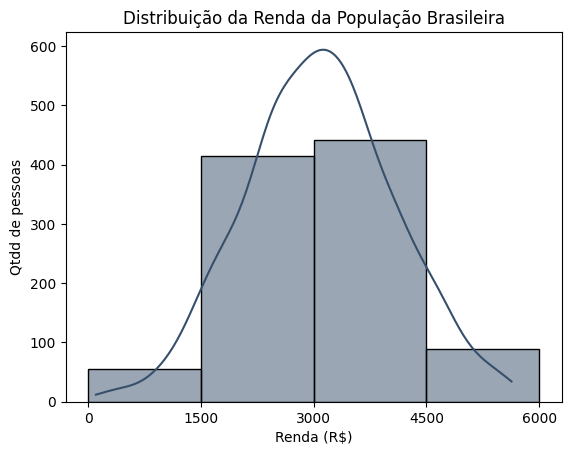

In [60]:
renda_maxima = df['renda'].max()
bins = np.arange(0, renda_maxima + 1500, 1500)

# Visualizando em um histograma

sns.histplot(data=df, x='renda', bins=bins, kde=True, color = '#364f6b')
plt.title('Distribuição da Renda da População Brasileira')
plt.xlabel('Renda (R$)')
plt.ylabel('Qtdd de pessoas')
plt.xticks(bins)
plt.show()

**Resposta:** A partir do Histograma, é possível verificar que a maior parte das pessoas brasileiras possuem renda na faixa de 3000,00 à 4500,00 reais.  

Além disso, a Função Densidade de Probabilidade, representada pela curva suavizada do KDE no gráfico, mostra uma distribuição contínua e unimodal, e permite calcular a probabilidade da renda de um brasileiro estar em qualquer intervalo contínuo por meio da área sob essa curva.

5. Calcule a média e a variância da renda da amostra. Depois faça a
distribuição normal, inclua o gráfico.

In [61]:
media_renda = df['renda'].mean()
variancia_renda = df['renda'].var()
desvio_padrao_renda = np.sqrt(variancia_renda)

print(f'Média da renda da amostra: R${round(media_renda,2)}.\nVariância da renda da amostra: {round(variancia_renda,2)}.\nDesvio Padrão da renda da amostra: R${round(desvio_padrao_renda,2)}')

Média da renda da amostra: R$3082.54.
Variância da renda da amostra: 993156.23.
Desvio Padrão da renda da amostra: R$996.57


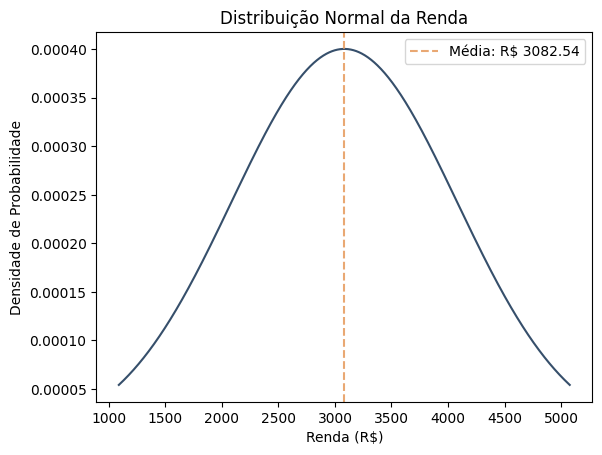

In [62]:
# Gráfico da distribuição

#inicio: média - 2*DP; fim: média + 2DP, qtdd de pontos: 1000 - intervalo de confiança: 95%
x = np.linspace(media_renda - 2*desvio_padrao_renda, media_renda + 2*desvio_padrao_renda, 1000)

# norm é específico para distribuições normais, pdf calcula a Função Densidade de Probabilidade
y = stats.norm.pdf(x, loc=media_renda, scale=desvio_padrao_renda)

plt.plot(x, y, color = '#364f6b')
plt.axvline(media_renda, color='#e9a873', linestyle='--', label=f'Média: R$ {round(media_renda, 2)}')
plt.title('Distribuição Normal da Renda')
plt.xlabel('Renda (R$)')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.show()


6. Primeiro considere a probabilidade encontrada no nosso conjunto de
pessoas com escolaridade de pós-graduação. Considerando a amostra
de população brasileira com 1 milhão de habitantes, qual a
probabilidade de encontrarmos 243 mil pessoas com pós-graduação?


In [63]:
pos_graduacao = (df['escolaridade'] == 'Pós-graduação').sum()
probabilidade_pos_graduacao = pos_graduacao / pessoas_total
porcentagem_pos_graduacao = probabilidade_pos_graduacao * 100

print(f'Na amostra, a probabilidade de encontrar pessoas com pós-graduação é de {round(probabilidade_pos_graduacao,4)} ou, {round(porcentagem_pos_graduacao, 2)}%.')

Na amostra, a probabilidade de encontrar pessoas com pós-graduação é de 0.253 ou, 25.3%.


In [64]:
k = 243000
n = 1000000

probabilidade_milhao_habitantes = stats.binom.pmf(k, n, probabilidade_pos_graduacao)

print(f'A probabilidade de encontrarmos 243 mil pessoas com pós graduação em uma população com 1 milhão de habitantes é de {probabilidade_milhao_habitantes}.')

# Anotações sobre a função stats.binom.pmf no exercício 9.

A probabilidade de encontrarmos 243 mil pessoas com pós graduação em uma população com 1 milhão de habitantes é de 1.1104854289794913e-119.


*Observações sobre a probabilidade encontrada:*  

Na prática, o número encontrado é tão baixo, que é praticamente impossível acertar o valor de 243 mil pessoas pós-graduadas em uma população de 1 milhão de habitantes. (O que não significa que é impossível existir 243 mil pessoas pós-graduadas nessa população, somente que a probabilidade de a população ter exatamente 243 mil pessoas (nem 243.001, nem 242.999) é infinitesimal).

7. Somando as densidades nós temos a função de densidade acumulada.
Considerando a coluna ‘Escolaridade’ faça a função de densidade
acumulada discreta para cada nível de escolaridade.


In [65]:
contagem_escolaridade = df['escolaridade'].value_counts()
ordem_escolaridade = ['Fundamental', 'Médio', 'Superior', 'Pós-graduação']
contagem_escolaridade = contagem_escolaridade.reindex(ordem_escolaridade)
contagem_escolaridade

,count
escolaridade,
Fundamental,266
Médio,238
Superior,243
Pós-graduação,253


In [66]:
proporcao_escolaridade = contagem_escolaridade / pessoas_total
proporcao_escolaridade

,count
escolaridade,
Fundamental,0.266
Médio,0.238
Superior,0.243
Pós-graduação,0.253


In [67]:
densidade_acumulada_escolaridade = proporcao_escolaridade.cumsum()

tabela_densidade = pd.DataFrame({
    'Qtdd Pessoas': contagem_escolaridade,
    'Proporção': proporcao_escolaridade,
    'Densidade Acumulada': densidade_acumulada_escolaridade
})

tabela_densidade

,Qtdd Pessoas,Proporção,Densidade Acumulada
escolaridade,,,
Fundamental,266,0.266,0.266
Médio,238,0.238,0.504
Superior,243,0.243,0.747
Pós-graduação,253,0.253,1.000


8. Qual a margem de erro amostral da proporção populacional
considerando a proporção de pessoas com nível de inglês
intermediário?

In [68]:
ingles_intermediario = (df['nível de proficiência em inglês'] == 'Intermediário').sum()
proporcao_ingles_intermediario = ingles_intermediario / pessoas_total
porcentagem_inglês_intermediario = proporcao_ingles_intermediario * 100

print(f'A proporção de pessoas com inglês intermediário é de {round(proporcao_ingles_intermediario, 4)}, ou {round(porcentagem_inglês_intermediario, 2)}%.')

A proporção de pessoas com inglês intermediário é de 0.329, ou 32.9%.


In [69]:
# Assumindo o termo de confiança de 95%, o Z score é de 1.96:

p = proporcao_ingles_intermediario
n = pessoas_total
z = 1.96

calculo_raiz = p * (1- p)
raiz = np.sqrt(calculo_raiz)
denominador = np.sqrt(n)
margem_erro = z * raiz / denominador

print(f'Assumindo a margem de confiança de 95%, a margem de erro amostral da proporção de pessoas com nível de inglês intermediário é de aproximadamente {round(margem_erro, 4)}.')

Assumindo a margem de confiança de 95%, a margem de erro amostral da proporção de pessoas com nível de inglês intermediário é de aproximadamente 0.0291.


9. Calcula a renda da população. Qual a probabilidade de encontrar 60
pessoas com uma renda mil reais superior à média?


In [70]:
renda_superior = round(media_renda + 1000.00, 2)
pessoas_renda_superior = (df['renda'] > renda_superior).sum()
proporcao_renda_amostra = pessoas_renda_superior / pessoas_total

probabilidade_60_pessoas = stats.binom.pmf(60, 60, proporcao_renda_amostra)
print(f"A probabilidade é de {probabilidade_60_pessoas}.")

A probabilidade é de 2.5677489595221674e-48.


*Observações sobre a probabilidade encontrada:*   

Este resultado tão próximo de zero mostra que, se você sortear um grupo de 60 pessoas na rua, a chance de todas elas ganharem um salário mil reais acima da média dessa amostra é praticamente nula.  

---


*Anotações sobre a função `binom.pmf` da biblioteca `stats`:*  

* `binom`: Vem de Binomial. Significa que o seu experimento só tem dois resultados possíveis: ou acontece o que você quer (Sucesso) ou não acontece (Fracasso).

* `pmf`: Significa Probability Mass Function (Função Massa de Probabilidade). É o termo matemático para dizer: "Me dá a probabilidade exata de acontecer esse número de sucessos".

**Parâmetros:**  

Em ordem de inserção:  
* O k (O que você quer encontrar): É o número exato de "sucessos" que se está buscando. No exercício: Você quer encontrar 60 pessoas com a renda 1000.00 reais superior à média. Então, k = 60.  
* O n (O tamanho do teste): É o número total de tentativas que serão feitas, ou o tamanho do grupo que você vai testar. No exercício: Se está extraindo um grupo de 60 pessoas para testar. Então, n = 60.
* O p (A chance de um único "sucesso"): É a probabilidade de o evento acontecer com uma única pessoa isolada. Esse valor vai de 0 a 1. No exercício: É a variável proporcao_renda_amostra.


10. Qual a probabilidade de escolhermos alguém do Sudeste que seja
homem, com ensino fundamental e com renda maior que 2 mil reais por
mês?

In [71]:
sudeste = (df['estado'] == 'SP') | (df['estado'] == 'RJ') | (df['estado'] == 'MG') | (df['estado'] == 'ES')

combinacao = sudeste & (df['escolaridade'] == 'Fundamental') & (df['sexo'] == 'M') & (df['renda'] > 2000.00)
combinacao = combinacao.sum()

probabilidade_escolha = combinacao / pessoas_total
porcentagem_escolha =  probabilidade_escolha * 100

print(f'A probabilidade de escolher alguém que atenda as condições é de {round(probabilidade_escolha, 4)}, ou {round(porcentagem_escolha, 2)}%.')

A probabilidade de escolher alguém que atenda as condições é de 0.019, ou 1.9%.


## Conclusão

A resolução destes exercícios permitiu colocar em prática conceitos essenciais de probabilidade e amostragem utilizando Python. Além de realizar os cálculos estatísticos, foi possível interpretar os resultados e compreender como essas técnicas podem ser aplicadas na análise de dados. Esses fundamentos são importantes para desenvolver análises mais confiáveis e embasar decisões orientadas por dados.